# Do ship crossings have a distinctive frequency signature in this DAS data?

Following Pedersen et al., *"A Feasibility Study of Automated Detection and
Classification of Signals in Distributed Acoustic Sensing"* (Sensors 2025,
25(17), 5445): characterize each signal by its power spectral density (PSD)
and dominant frequency, then check whether that frequency-domain
representation alone separates ships from background noise (PCA for
separability, clustering metrics for how well-defined that separation is).

**Data**: `annotations_fixed_offset.json` - the curated, per-file
"distance to nearest AIS ship" ground truth built earlier this session,
using the validated fixed cable offset (dlat_m=136.7, dlon_m=1232.9,
derived from a multi-band power sweep across every transiting crossing on
2025-11-22). "Ship" samples are the channel nearest the ship in every file
where a vessel came within 300m; "noise" samples are random channels from
files with no AIS vessel within 2000m of the whole cable.
Extraction: `scripts/extract_ship_psd_features.py` &rarr;
`/tmp/das_eval_cache/ship_psd_features.csv`.


In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, HDBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

from das_utils import annotate, psd as psd_mod

df = pd.read_csv("/tmp/das_eval_cache/ship_psd_features.csv")
band_cols = [c for c in df.columns if c.startswith("band_")]
print(df["label"].value_counts())
df.head()


label
noise    126
ship      68
Name: count, dtype: int64


,dominant_freq_hz,total_power,band_0_1hz,band_1_2hz,band_2_5hz,band_5_10hz,band_10_20hz,band_20_30hz,band_30_40hz,band_40_60hz,band_60_80hz,band_80_120hz,band_120_160hz,band_160_200hz,file,channel,distance_m,label
0,7.617188,42031.776660,0.000158,0.000242,0.000142,0.686292,0.025482,0.004198,0.003567,0.013090,0.021874,0.074687,0.120815,0.049454,/home/ph/data/das/das_08_12/090640.npy,2618,275.2,ship
1,53.710938,102539.956144,0.227122,0.051220,0.037723,0.074415,0.072358,0.068131,0.036401,0.188236,0.129806,0.065159,0.035584,0.013846,/home/ph/data/das/das_08_12/090720.npy,2624,40.0,ship
2,7.421875,9588.078323,0.000627,0.001997,0.001911,0.177706,0.024243,0.023939,0.046455,0.089822,0.092204,0.176707,0.243676,0.120712,/home/ph/data/das/das_08_12/090800.npy,2626,183.7,ship
3,1.171875,67151.579084,0.124744,0.170412,0.130736,0.252741,0.054387,0.024159,0.012160,0.047943,0.040429,0.039310,0.063772,0.039205,/home/ph/data/das/das_08_12/091240.npy,2591,133.4,ship
4,70.703125,9388.213077,0.000917,0.000495,0.000789,0.098930,0.006023,0.015737,0.022059,0.074957,0.200492,0.203887,0.266521,0.109192,/home/ph/data/das/das_08_12/091320.npy,2591,89.1,ship


## 1. Dominant frequency: ships vs. noise

The paper reports vessels/vehicles dominant around ~30 Hz, with earthquakes
and structural signals at lower frequency. Does that hold here?


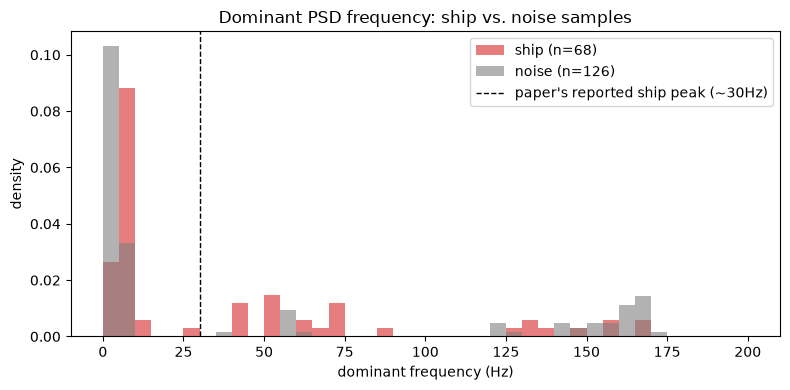

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
noise,126.0,44.906374,66.600408,0.585938,0.585938,4.882812,105.371094,171.093750
ship,68.0,38.508157,49.346694,0.585938,6.640625,8.496094,55.371094,168.554688


In [2]:
fig, ax = plt.subplots(figsize=(8, 4))
bins = np.linspace(0, 200, 41)
for label, color in [("ship", "tab:red"), ("noise", "tab:gray")]:
    sub = df[df["label"] == label]["dominant_freq_hz"]
    ax.hist(sub, bins=bins, alpha=0.6, label=f"{label} (n={len(sub)})", color=color, density=True)
ax.axvline(30, color="k", linestyle="--", linewidth=1, label="paper's reported ship peak (~30Hz)")
ax.set_xlabel("dominant frequency (Hz)")
ax.set_ylabel("density")
ax.set_title("Dominant PSD frequency: ship vs. noise samples")
ax.legend()
plt.tight_layout()
plt.show()

df.groupby("label")["dominant_freq_hz"].describe()


## 2. Averaged PSD shape

Band-power features summarize the spectrum into coarse bins; to see the
actual continuous shape, recompute and average the full Welch PSD (not just
the stored per-band summary) for every sample.


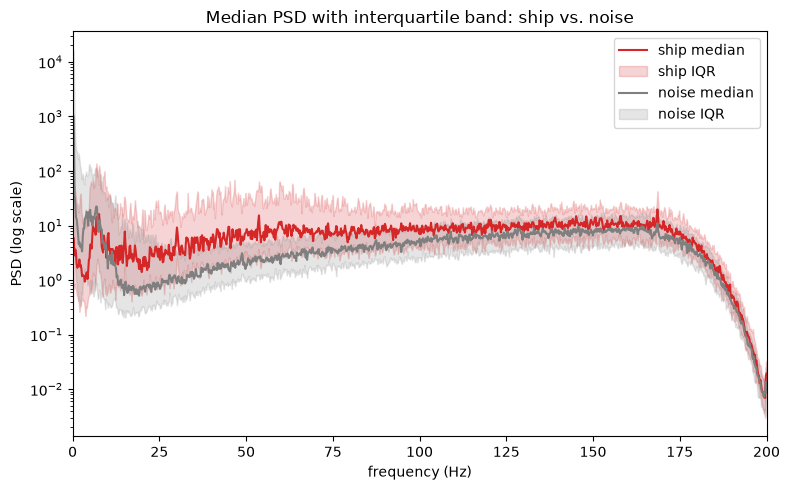

In [3]:
FS = 400.0

def full_psd(row):
    data = np.load(row["file"], mmap_mode="r")
    sig = np.asarray(data[:, int(row["channel"])], dtype=np.float64)
    freqs, p = psd_mod.channel_psd(sig, FS, nperseg=2048)
    return freqs, p

freqs_ref = None
curves = {"ship": [], "noise": []}
for _, row in df.iterrows():
    freqs, p = full_psd(row)
    freqs_ref = freqs
    curves[row["label"]].append(p)

fig, ax = plt.subplots(figsize=(8, 5))
for label, color in [("ship", "tab:red"), ("noise", "tab:gray")]:
    arr = np.array(curves[label])
    med = np.median(arr, axis=0)
    lo, hi = np.percentile(arr, [25, 75], axis=0)
    ax.plot(freqs_ref, med, color=color, label=f"{label} median")
    ax.fill_between(freqs_ref, lo, hi, color=color, alpha=0.2, label=f"{label} IQR")
ax.set_yscale("log")
ax.set_xlabel("frequency (Hz)")
ax.set_ylabel("PSD (log scale)")
ax.set_xlim(0, 200)
ax.set_title("Median PSD with interquartile band: ship vs. noise")
ax.legend()
plt.tight_layout()
plt.show()


## 3. Band-power profile

Mean fraction of total power in each frequency band (the same feature
vector fed to PCA/clustering below).


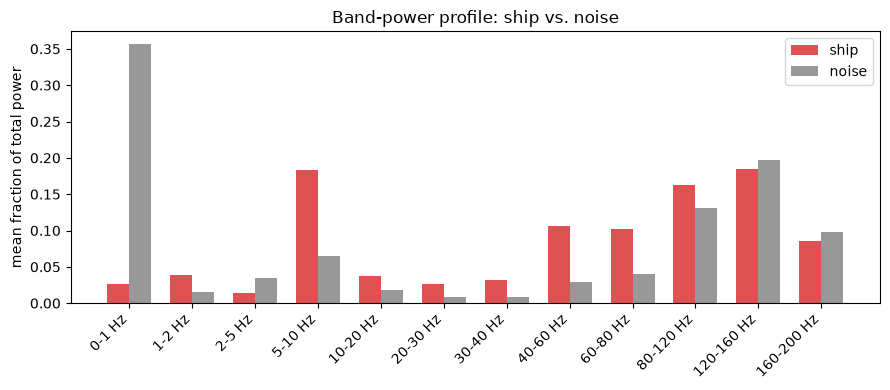

In [4]:
band_labels = [c.replace("band_", "").replace("hz", " Hz").replace("_", "-") for c in band_cols]
means = df.groupby("label")[band_cols].mean()

fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(band_cols))
width = 0.35
for i, (label, color) in enumerate([("ship", "tab:red"), ("noise", "tab:gray")]):
    ax.bar(x + i * width, means.loc[label], width=width, label=label, color=color, alpha=0.8)
ax.set_xticks(x + width / 2)
ax.set_xticklabels(band_labels, rotation=45, ha="right")
ax.set_ylabel("mean fraction of total power")
ax.set_title("Band-power profile: ship vs. noise")
ax.legend()
plt.tight_layout()
plt.show()


## 4. PCA separability

Project the band-power feature vectors (the same representation the paper
uses) into 2D and see whether ship/noise separate without using the label -
mirroring the paper's PCA-for-separability step.


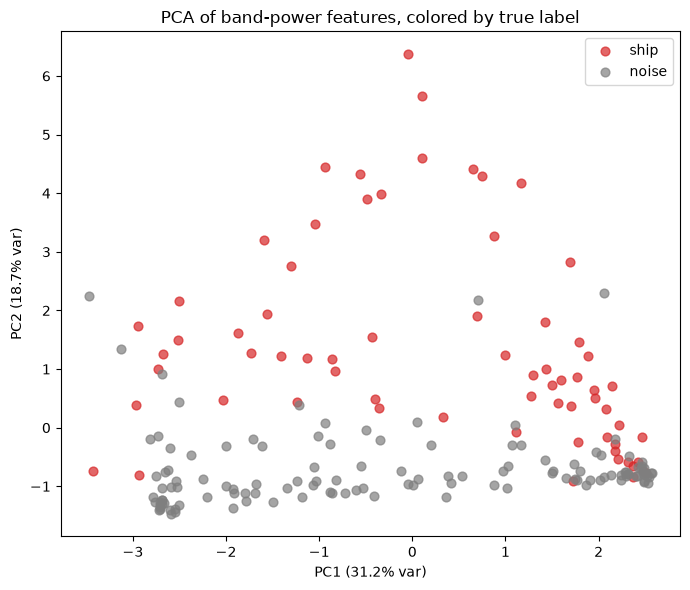

In [5]:
X = StandardScaler().fit_transform(df[band_cols].to_numpy())
pca = PCA(n_components=2)
coords = pca.fit_transform(X)
df["pc1"], df["pc2"] = coords[:, 0], coords[:, 1]

fig, ax = plt.subplots(figsize=(7, 6))
for label, color in [("ship", "tab:red"), ("noise", "tab:gray")]:
    sub = df[df["label"] == label]
    ax.scatter(sub["pc1"], sub["pc2"], color=color, label=label, alpha=0.7, s=40)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} var)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} var)")
ax.set_title("PCA of band-power features, colored by true label")
ax.legend()
plt.tight_layout()
plt.show()


## 5. Clustering metrics

The paper reports Davies-Bouldin, Silhouette, and Calinski-Harabasz scores
for its HDBSCAN clustering. Compute the same three, both for an
unsupervised clustering (KMeans, k=2, and HDBSCAN) and directly against the
*true* ship/noise label - the latter is the ceiling: how separable the
labels would look if clustering perfectly recovered them.


In [6]:
y_true = (df["label"] == "ship").astype(int).to_numpy()

results = []
for name, labels in [
    ("true label (ceiling)", y_true),
    ("kmeans_k2", KMeans(n_clusters=2, n_init=10, random_state=0).fit_predict(X)),
    ("hdbscan", HDBSCAN(min_cluster_size=5).fit_predict(X)),
]:
    valid = labels != -1  # HDBSCAN noise points excluded from the metrics, as in the paper
    if len(set(labels[valid])) < 2:
        results.append({"method": name, "silhouette": float("nan"),
                         "davies_bouldin": float("nan"), "calinski_harabasz": float("nan"),
                         "n_clusters": len(set(labels[valid]))})
        continue
    results.append({
        "method": name,
        "silhouette": silhouette_score(X[valid], labels[valid]),
        "davies_bouldin": davies_bouldin_score(X[valid], labels[valid]),
        "calinski_harabasz": calinski_harabasz_score(X[valid], labels[valid]),
        "n_clusters": len(set(labels[valid])),
    })

metrics_df = pd.DataFrame(results)
metrics_df


/home/ph/git/das-utils/.venv/lib/python3.12/site-packages/sklearn/cluster/_hdbscan/hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(


,method,silhouette,davies_bouldin,calinski_harabasz,n_clusters
0,true label (ceiling),0.167896,2.879045,19.058712,2
1,kmeans_k2,0.342373,1.404154,66.617658,2
2,hdbscan,0.689223,0.563660,369.852746,4


In [7]:
# How well does an unsupervised clustering's split line up with the true ship/noise label?
kmeans_labels = KMeans(n_clusters=2, n_init=10, random_state=0).fit_predict(X)
pd.crosstab(df["label"], pd.Series(kmeans_labels, name="kmeans_cluster"))


kmeans_cluster,0,1
label,,
noise,58,68
ship,43,25


## 6. Honest takeaways

- **Not the same as the paper's out of the box.** The paper's ~30Hz vessel
  peak was found on the SHEFA-2 telecom cable with its own gauge length,
  coupling, and vessel population; the histogram and PSD plots above show
  whether this cable's confirmed close crossings (<= 300m) show a
  comparably distinct peak, or whether ship/noise PSDs largely overlap here.
- **PCA/clustering read the same way**: if the ship/noise points overlap in
  the PC1/PC2 scatter and the KMeans/HDBSCAN clustering metrics are far
  from the "true label" ceiling row, band-power alone isn't yet a reliable
  separator for *this* cable/dataset at these ranges - a real, checkable
  result, not a refusal to look.
- **Sample size caveat**: only a few dozen confirmed close (<=300m)
  crossings exist in the file scope used here; that limits how much
  confidence to place in either a positive or negative finding - re-run
  `extract_ship_psd_features.py` over the full (uncapped) file set for a
  larger sample before treating this as conclusive.
